## **Population and sample regression analysis**

In [117]:
import numpy as np
import matplotlib.pyplot as plt

In [127]:
# generating random data

n = 1000
alpha = 2.2
beta = 0.6
sigma = 1.5 # std of the disturbance 

x = np.random.uniform(1, 10, n)
epsilon = np.random.normal(0, sigma, n)
y = alpha + beta * x + epsilon

In [128]:
x_bar = np.mean(x)
y_bar = np.mean(y)

beta_hat = np.sum((x - x_bar) * (y - y_bar))/np.sum((x - x_bar)**2)
alpha_hat = y_bar - (beta_hat * x_bar)

print(f"True beta: {beta}, Estimated beta: {beta_hat:.4f}")
print(f"True alpha: {alpha}, Estimated alpha: {alpha_hat:.4f}")

True beta: 0.6, Estimated beta: 0.5927
True alpha: 2.2, Estimated alpha: 2.2264


In [129]:
# compute The RSS

y_hat = alpha_hat + beta_hat * x
residuals = y - y_hat
RSS = np.sum(residuals**2)

In [130]:
var_biased = RSS / n
var_unbiased = RSS / (n - 2)

In [131]:
var_x = np.sum((x - x_bar)**2)
sum_x_sq = np.sum(x**2)

In [132]:
SE_beta = np.sqrt(var_unbiased / var_x)
SE_alpha = np.sqrt((var_unbiased * sum_x_sq )/(n * var_x))

In [133]:
print(f"Biased variance: {var_biased:.4f}")
print(f"Unbiased variance: {var_unbiased:.4f}")
print(f"SE(beta): {SE_beta:.4f}")
print(f"SE(alpha): {SE_alpha:.4f}")

Biased variance: 2.2222
Unbiased variance: 2.2267
SE(beta): 0.0182
SE(alpha): 0.1121


In [110]:
# Sampling
n_s = 500
sample_idx = np.random.choice(n , size=n_s, replace=False)
x_s = x[sample_idx]
y_s = y[sample_idx]

In [111]:
x_bar_s = np.sum(x_s) / len(x_s)
y_bar_s = np.sum(y_s) / len(y_s)
beta_hat_s = np.sum((x_s - x_bar_s) * (y_s - y_bar_s))/ np.sum((x_s - x_bar_s)**2)
alpha_hat_s = y_bar_s - beta_hat_s * x_bar_s

In [112]:
y_hat_s = alpha_hat_s + beta_hat_s * x_s
residuals_s = y_s - y_hat_s
RSS_s = np.sum(residuals_s**2)

In [113]:
var_biased_s = RSS_s / n_s
var_unbiased_s = RSS_s / (n_s - 2)

In [114]:
var_x_s = np.sum((x_s - x_bar_s)**2)
sum_x_sq_s = np.sum(x_s**2)

In [115]:
SE_beta_s = np.sqrt(var_unbiased_s / var_x_s)
SE_alpha_s = np.sqrt((var_unbiased_s * sum_x_sq_s )/(n_s * var_x_s))

In [116]:
print(f"Biased variance: population={var_biased:.4f}, sample={var_biased_s:.4f}")
print(f"Unbiased variance: population={var_unbiased:.4f}, sample={var_unbiased_s:.4f}")
print(f"SE(beta): population={SE_beta:.4f}, sample={SE_beta_s:.4f}")
print(f"SE(alpha): population={SE_alpha:.4f}, sample={SE_alpha_s:.4f}")

Biased variance: population=2.1473, sample=2.2818
Unbiased variance: population=2.1516, sample=2.2909
SE(beta): population=0.0183, sample=0.0269
SE(alpha): population=0.1123, sample=0.1646


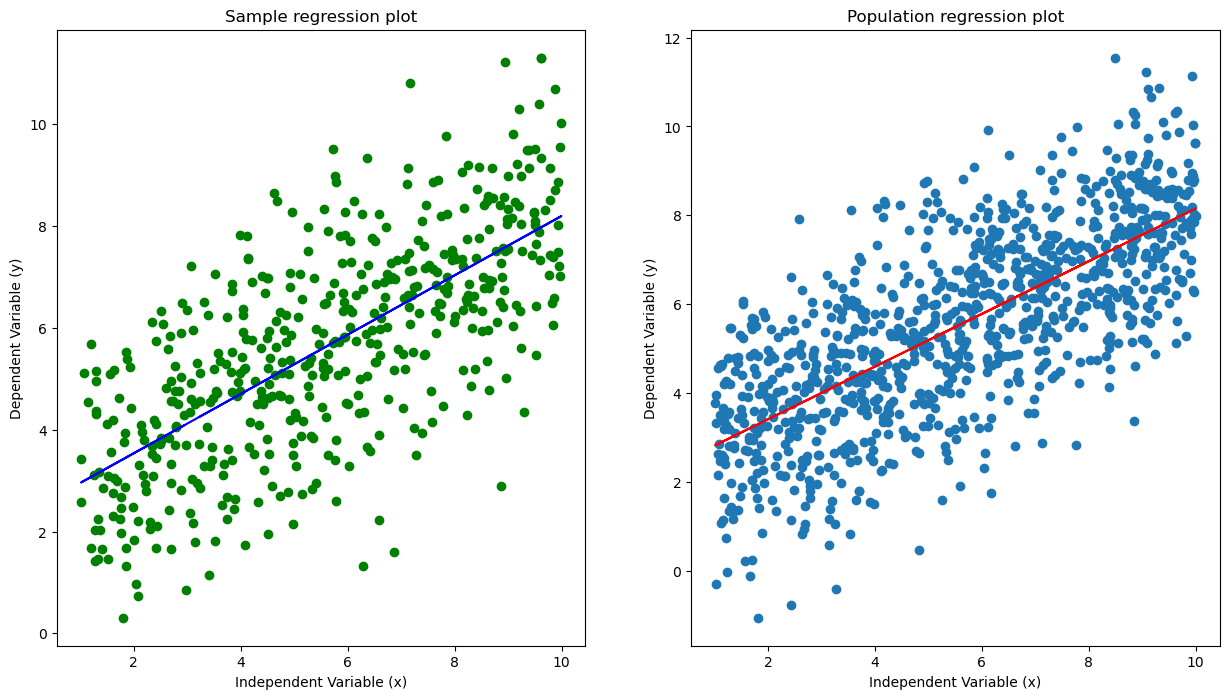

In [145]:
plt.figure(figsize=(15,8))
plt.subplot(121)
plt.scatter(x_s, y_s, c="g")
plt.plot(x_s, y_hat_s, "b-")
plt.xlabel("Independent Variable (x)")
plt.ylabel("Dependent Variable (y)")
plt.title("Sample regression plot")
plt.subplot(122)
plt.scatter(x, y)
plt.plot(x, y_hat, "r-")
plt.xlabel("Independent Variable (x)")
plt.ylabel("Dependent Variable (y)")
plt.title("Population regression plot")
plt.show()